# Installs

In [1]:
!pip install --upgrade pip
!pip uninstall -y flax jax jaxlib grain tiktoken gradio
# !pip install "jax[cuda12]==0.4.26" jaxlib==0.4.26 flax==0.8.4 grain tiktoken gradio --force-reinstall --no-cache-dir
!pip install "jax[cuda12]==0.4.26" jaxlib==0.4.26 flax==0.8.4 grain tiktoken gradio
!pip install huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: flax 0.11.2
Uninstalling flax-0.11.2:
  Successfully uninstalled flax-0.11.2
Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: grain 0.2.17
Uninstalling grain-0.2.17:
  Successfully uninstalled grain-0.2.17
Found existing installation: tiktoken 0.13.0
Uninstalling tiktoken-0.13.0:
  Successfully uninstalled tiktoken-0.13.0
Found existing installation: gradio 5.50.0
Uninstalling gradio-5.50.0:
  Successfully uninstalled gradio-5.50.0
INFO: pip is looking at multiple versions of optax to determine which version is compatible with other requirements. This coul

### Mount my drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# L4: Training the Model

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [3]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import tiktoken
from datasets import load_dataset

import optax
import sys

sys.path.append('/content/drive/MyDrive/Ade-Colab-Notebooks/Large-Language-Models/gpt-jax-demo-another_one')

In [4]:
from helper import MiniGPT, load_and_preprocess_data, generate_text

<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> file:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.</p>

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>

<p> 📒 &nbsp; For more help, please see the <em>"Appendix – Tips, Help, and Download"</em> Lesson.</p>
</div>

### Configurations

In [5]:
CONTENT_PATH = '/content/drive/MyDrive/Ade-Colab-Notebooks/Large-Language-Models/gpt-jax-demo-another_one'
TINY_STORIES_ALL_DATA_FILE_PATH = f"{CONTENT_PATH}/TinyStories-1000.txt"
# DATA_FILE_PATH = f"{CONTENT_PATH}/TinyStories-1000.txt"
DATA_FILE_PATH = f"{CONTENT_PATH}/tinystories-10000.txt"

In [6]:
maxlen=128
tokenizer = tiktoken.get_encoding("gpt2")

In [7]:
text_dl, batches_per_epoch = load_and_preprocess_data(
    file_path=DATA_FILE_PATH,
    batch_size=32,
    maxlen=128,
    max_stories=100_000,
    shuffle=False,
    seed=42
)

Loading data from /content/drive/MyDrive/Ade-Colab-Notebooks/Large-Language-Models/gpt-jax-demo-another_one/tinystories-10000.txt (max 100,000 stories)
Loaded 50,893 stories
Estimated batches per epoch: 1,590
Created DataLoader with batch_size=32, maxlen=128


In [8]:
model = MiniGPT()

#### Visualize the model

In [9]:
model

MiniGPT(
  maxlen=128,
  embedding=TokenAndPositionEmbedding(
    token_emb=Embed(
      embedding=Param(
        value=Array(shape=(50257, 192), dtype=float32)
      ),
      num_embeddings=50257,
      features=192,
      dtype=dtype('float32'),
      param_dtype=<class 'jax.numpy.float32'>,
      embedding_init=<function variance_scaling.<locals>.init at 0x7f34b20e59e0>
    ),
    pos_emb=Embed(
      embedding=Param(
        value=Array(shape=(128, 192), dtype=float32)
      ),
      num_embeddings=128,
      features=192,
      dtype=dtype('float32'),
      param_dtype=<class 'jax.numpy.float32'>,
      embedding_init=<function variance_scaling.<locals>.init at 0x7f34b20e59e0>
    )
  ),
  transformer_blocks=List(
    0=TransformerBlock(
      attention=MultiHeadAttention(
        num_heads=6,
        in_features=192,
        qkv_features=192,
        out_features=192,
        dtype=None,
        param_dtype=<class 'jax.numpy.float32'>,
        broadcast_dropout=True,
        drop

In [10]:
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits, targets
    ).mean()
    return loss, logits

In [11]:
num_epochs=3
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 4,770
Warmup steps: 477


In [12]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5
)

## Use an optimizer from optax

In [13]:
optimizer = nnx.Optimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01)
)

In [14]:
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

## Define and JIT-compile the training step

In [15]:
@nnx.jit
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1])
    optimizer.update(grads)

## Run the training loop

In [16]:
metrics_history = {'train_loss': []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(
            jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 10 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1

..........
Epoch: 1, Step 10, Loss: 10.9896, LR: 5.66e-06
..........
Epoch: 1, Step 20, Loss: 10.8747, LR: 1.19e-05
..........
Epoch: 1, Step 30, Loss: 10.5041, LR: 1.82e-05
..........
Epoch: 1, Step 40, Loss: 9.9381, LR: 2.45e-05
..........
Epoch: 1, Step 50, Loss: 8.8781, LR: 3.08e-05
..........
Epoch: 1, Step 60, Loss: 6.7639, LR: 3.71e-05
..........
Epoch: 1, Step 70, Loss: 5.5977, LR: 4.34e-05
..........
Epoch: 1, Step 80, Loss: 4.8068, LR: 4.97e-05
..........
Epoch: 1, Step 90, Loss: 4.3962, LR: 5.60e-05
..........
Epoch: 1, Step 100, Loss: 4.2873, LR: 6.23e-05
..........
Epoch: 1, Step 110, Loss: 3.7982, LR: 6.86e-05
..........
Epoch: 1, Step 120, Loss: 2.9646, LR: 7.48e-05
..........
Epoch: 1, Step 130, Loss: 3.2448, LR: 8.11e-05
..........
Epoch: 1, Step 140, Loss: 3.5593, LR: 8.74e-05
..........
Epoch: 1, Step 150, Loss: 2.8998, LR: 9.37e-05
..........
Epoch: 1, Step 160, Loss: 2.2203, LR: 1.00e-04
..........
Epoch: 1, Step 170, Loss: 2.1836, LR: 1.06e-04
..........
Epoch: 1,

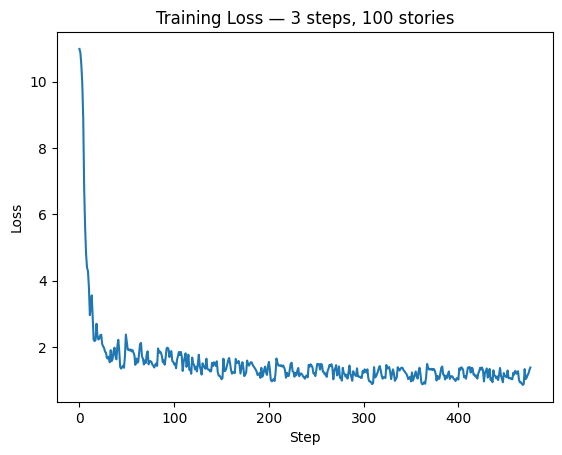

In [17]:
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss — 3 steps, 100 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Training loss for 3 epochs, 2,000,000 stories

<img src="training_loss.png" width="570">


## Save model checkpoints

In [18]:
from pathlib import Path
import orbax

checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /content/small_checkpoint.orbax


### Compress the model checkpoint file

In [19]:
! tar -czvf small_jax_gpt.tar.gz $checkpoint_path

tar: Removing leading `/' from member names
/content/small_checkpoint.orbax/
/content/small_checkpoint.orbax/_sharding
/content/small_checkpoint.orbax/_CHECKPOINT_METADATA
/content/small_checkpoint.orbax/_METADATA
/content/small_checkpoint.orbax/ocdbt.process_0/
/content/small_checkpoint.orbax/ocdbt.process_0/manifest.ocdbt
/content/small_checkpoint.orbax/ocdbt.process_0/d/
/content/small_checkpoint.orbax/ocdbt.process_0/d/0122cc74073141ea1907f02277e4bfa2
/content/small_checkpoint.orbax/ocdbt.process_0/d/3c392169d6bde6decb3d9268ab55c065
/content/small_checkpoint.orbax/ocdbt.process_0/d/01b75c67fdac15b469da85f54acf0743
/content/small_checkpoint.orbax/ocdbt.process_0/d/d0cb66822a98d4fc01cdfd3ab4b61580
/content/small_checkpoint.orbax/ocdbt.process_0/d/c514a47e3f5b52c1c4df72bb0a6988f1
/content/small_checkpoint.orbax/manifest.ocdbt
/content/small_checkpoint.orbax/d/
/content/small_checkpoint.orbax/d/9ff56f0451d8028c640171b36ae0ff36


In [20]:
from tiny_stories_dataset_provider import getPartTinyStoriesDataset, getTinyStoriesDataset

In [21]:
getTinyStoriesDataset()

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Writing stories to tinystories.txt...
Finished successfully!


In [22]:
getPartTinyStoriesDataset(
    input_file_path="tinystories.txt",
    output_file_path="tinystories-10000.txt"
    )

Successfully saved the first 101000 lines to tinystories-10000.txt


### Compress the model file

In [23]:
!tar -czvf small_checkpoint.orbax.tar.gz small_checkpoint.orbax

small_checkpoint.orbax/
small_checkpoint.orbax/_sharding
small_checkpoint.orbax/_CHECKPOINT_METADATA
small_checkpoint.orbax/_METADATA
small_checkpoint.orbax/ocdbt.process_0/
small_checkpoint.orbax/ocdbt.process_0/manifest.ocdbt
small_checkpoint.orbax/ocdbt.process_0/d/
small_checkpoint.orbax/ocdbt.process_0/d/0122cc74073141ea1907f02277e4bfa2
small_checkpoint.orbax/ocdbt.process_0/d/3c392169d6bde6decb3d9268ab55c065
small_checkpoint.orbax/ocdbt.process_0/d/01b75c67fdac15b469da85f54acf0743
small_checkpoint.orbax/ocdbt.process_0/d/d0cb66822a98d4fc01cdfd3ab4b61580
small_checkpoint.orbax/ocdbt.process_0/d/c514a47e3f5b52c1c4df72bb0a6988f1
small_checkpoint.orbax/manifest.ocdbt
small_checkpoint.orbax/d/
small_checkpoint.orbax/d/9ff56f0451d8028c640171b36ae0ff36
